In [1]:
# Import PPI

import pandas as pd
import networkx as nx

df = pd.read_csv("PPI_physical_elist.csv", header=None)
df.columns = ['protein1', 'protein2']  # manually name the columns

G = nx.from_pandas_edgelist(df, source='protein1', target='protein2')

In [2]:
# Check size of PPI and change node names to str

print(len(G.edges()))
print(len(G.nodes()))

nx.relabel_nodes(G, lambda x: str(x), copy=False)

first_node = next(iter(G.nodes))
print(type(first_node))


for i, component in enumerate(nx.connected_components(G), 1):
    print(f"Component {i}: {len(component)} nodes")

306914
18068
<class 'str'>
Component 1: 18064 nodes
Component 2: 4 nodes


In [3]:
# Read disease modules

import pickle

with open('d_doup_genes.pkl', 'rb') as file:
    disease_genes = pickle.load(file)

print(len(disease_genes))

3911


In [4]:
# Read the doid_to_name dictionary and compute the name_to_doid

import json

with open("doid_to_name.json", "r") as f:
    doid_to_name = json.load(f)
    
    
name_to_doid = {v: k for k, v in doid_to_name.items()}

In [5]:
# Function that prints graph stats of a given graph

def print_graph_stats(G):
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())
    degrees = [deg for _, deg in G.degree()]
    print("Max degree:", max(degrees))
    print("Min degree:", min(degrees))
    print("Average clustering coefficient:", nx.average_clustering(G) if not G.is_directed() else "N/A")
    print("Diameter:", nx.diameter(G) if nx.is_connected(G) else "graph is not connected")

print_graph_stats(G)

Number of nodes: 18068
Number of edges: 306914
Average degree: 33.97321230905468
Max degree: 2344
Min degree: 1
Average clustering coefficient: 0.07852682740590607
Diameter: graph is not connected


In [6]:
# Function to compute largest connected component of given disease

def compute_lcc_of_disease(disease_id):
    subgraph_nodes = disease_genes[disease_id]
    subgraph = G.subgraph(subgraph_nodes).copy()

    try:
        largest_cc_nodes = max(nx.connected_components(subgraph), key=len)
        largest_cc_subgraph = subgraph.subgraph(largest_cc_nodes).copy()
        return largest_cc_nodes, largest_cc_subgraph
    
    except ValueError as e:
        return None, None

In [7]:
# Compute size of lcc for all diseases

from collections import Counter

disease_lengths = []

for disease in disease_genes.keys():
    nodes, _ = compute_lcc_of_disease(disease)
    if nodes is not None:
        disease_lengths.append(len(nodes))


gene_size_counts = Counter(disease_lengths)
print(gene_size_counts)

Counter({1: 1936, 2: 486, 3: 255, 4: 200, 5: 81, 7: 61, 6: 55, 13: 46, 25: 40, 9: 38, 41: 37, 8: 32, 16: 30, 19: 30, 10: 26, 15: 24, 21: 19, 17: 18, 20: 18, 23: 17, 26: 17, 50: 16, 14: 15, 12: 13, 24: 11, 32: 8, 11: 7, 44: 7, 35: 7, 18: 7, 43: 6, 39: 6, 94: 6, 88: 6, 36: 5, 42: 5, 133: 5, 57: 5, 28: 5, 29: 5, 75: 5, 49: 4, 64: 4, 125: 4, 95: 4, 46: 4, 104: 4, 22: 4, 30: 4, 73: 4, 146: 3, 27: 3, 127: 3, 85: 3, 139: 3, 67: 3, 34: 3, 112: 3, 48: 3, 37: 3, 89: 3, 158: 3, 244: 2, 350: 2, 588: 2, 409: 2, 412: 2, 99: 2, 157: 2, 155: 2, 149: 2, 53: 2, 45: 2, 443: 2, 453: 2, 47: 2, 92: 2, 284: 2, 150: 2, 154: 2, 196: 2, 153: 2, 181: 2, 141: 2, 241: 2, 188: 2, 243: 2, 81: 2, 33: 2, 98: 2, 86: 2, 115: 2, 118: 2, 55: 2, 59: 2, 70: 2, 108: 2, 109: 2, 123: 2, 68: 1, 203: 1, 2192: 1, 2294: 1, 2430: 1, 6294: 1, 396: 1, 4030: 1, 209: 1, 852: 1, 602: 1, 694: 1, 383: 1, 498: 1, 276: 1, 232: 1, 597: 1, 709: 1, 1263: 1, 258: 1, 405: 1, 210: 1, 370: 1, 285: 1, 326: 1, 164: 1, 954: 1, 2287: 1, 697: 1, 422: 1

In [15]:
# Function to reconstruct the lcc of a given disease based on first/last/first-last k eigenpairs and plot it

from scipy.stats import wasserstein_distance
from networkx import all_pairs_shortest_path_length
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt


def reconstruct_lcc_graph(disease_name, k, method):
    disease_id = name_to_doid[disease_name]
    lcc_nodes, lcc = compute_lcc_of_disease(disease_id)
    L_lcc = nx.normalized_laplacian_matrix(lcc).toarray()
    eigenvalues, eigenvectors = LA.eigh(L_lcc)
    
    if method == 'first_k':
        selected_indices = np.arange(k)
    elif method == 'last_k':
        selected_indices = np.arange(-k, 0)
    elif method == 'first_last_k_over_2':
        k_half = k // 2
        selected_indices = np.concatenate([np.arange(k_half), np.arange(-k_half, 0)])
    else:
        raise ValueError(f"Unknown method: {method}")

    
    # Reconstruct the adjacency matrix
    U_k = eigenvectors[:, selected_indices]
    lambda_k = eigenvalues[selected_indices]
    S_k = U_k @ np.diag(1 - lambda_k) @ U_k.T
    degrees = np.array([d for _, d in lcc.degree()])
    D_sqrt = np.diag(np.sqrt(degrees))
    A_k = D_sqrt @ S_k @ D_sqrt

    # Cleaning
    np.fill_diagonal(A_k, 0)
    A_k = (A_k + A_k.T) / 2
    A_k[A_k < 0] = 0
    

    # Reconstruct the graph from the adjacency matrix
    reconstructed_graph = nx.Graph()
    
    N = len(lcc.edges())  # Number of edges in original graph

    n = A_k.shape[0]

    for i in range(n):
        for j in range(i+1, n):
            weight = A_k[i, j]
            if weight > 0:
                reconstructed_graph.add_edge(i, j, weight=weight)
                
                
    # Sort edges by descending weight
    edges_with_weights = sorted(
        [(u, v, d['weight']) for u, v, d in reconstructed_graph.edges(data=True)],
        key=lambda x: x[2],
        reverse=True
    )

    # Initialize an empty graph with the same nodes as original one
    top_graph = nx.Graph()
    top_graph.add_nodes_from(reconstructed_graph.nodes())

    # Add edges until the graph has the same number of edges as original one
    for u, v, w in edges_with_weights:
        top_graph.add_edge(u, v, weight=w)
        if top_graph.number_of_edges() == lcc.number_of_edges():
            break
          
                

                
     
    # Plot the reconstruction 
    
    # Get the node labels from lcc in the same order as used to compute the Laplacian matrix
    original_nodes = list(lcc.nodes())

    # Relabel the nodes in reconstructed_graph
    mapping = {i: node for i, node in enumerate(original_nodes)}
    top_graph = nx.relabel_nodes(top_graph, mapping)

    pos = nx.spring_layout(lcc, seed=50)
    plt.figure(figsize=(6, 4))

    # Nodes (same for both graphs)
    nx.draw_networkx_nodes(lcc, pos, node_color='black', node_size=50)

    # Edges
    original_edges = set(tuple(sorted(edge)) for edge in lcc.edges())
    reconstructed_edges = set(tuple(sorted(edge)) for edge in top_graph.edges())

    common_edges = original_edges & reconstructed_edges
    only_original = original_edges - reconstructed_edges
    only_reconstructed = reconstructed_edges - original_edges

    # Draw original-only edges: light gray
    nx.draw_networkx_edges(lcc, pos, edgelist=list(only_original), edge_color='lightgrey', alpha=0.5, label='Original Only')

    # Draw reconstructed-only edges: red
    nx.draw_networkx_edges(top_graph, pos, edgelist=list(only_reconstructed), edge_color='red', width=2, label='Reconstructed Only')

    # Draw common edges: green
    nx.draw_networkx_edges(top_graph, pos, edgelist=list(common_edges), edge_color='green', width=2, label='Common Edges')


    plt.axis('off')
    #plt.legend()
    plt.tight_layout()
    plt.savefig(f"{disease_name}_{method}.png", dpi = 300)
    plt.show()
    

    tp = len(original_edges & reconstructed_edges)
    overlap = tp/N

    print("Overlap:", overlap)

In [17]:
# Function that computes all three reconstructions (based on first/last/first-last eigenpairs) for a list of diseases

def plot_reconstr_for_disease_group(disease_list):
    for disease in disease_list:
        disease_id = name_to_doid[disease]
        lcc_nodes, lcc = compute_lcc_of_disease(disease_id)
        number_of_nodes_in_lcc = len(lcc_nodes)
        print("k = ", number_of_nodes_in_lcc//4)
        reconstruct_lcc_graph(disease, number_of_nodes_in_lcc//4, 'first_k')
        reconstruct_lcc_graph(disease, number_of_nodes_in_lcc//4, 'last_k')
        #reconstruct_lcc_graph(disease, number_of_nodes_in_lcc//4, 'first_last_k_over_2')
        print("############################################################")

k =  7


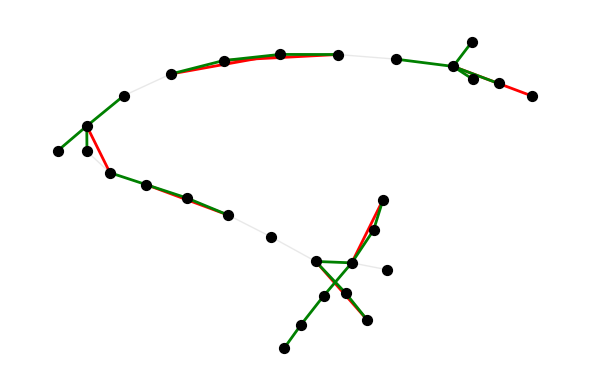

Overlap: 0.75


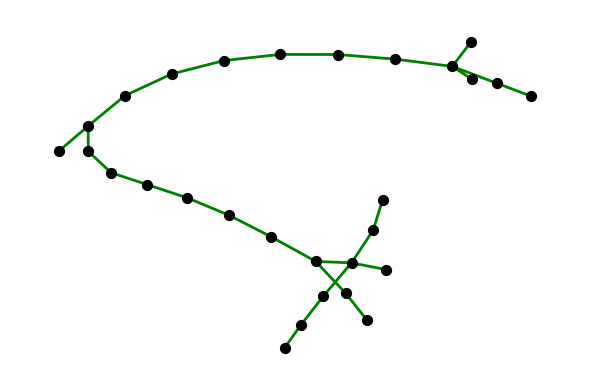

Overlap: 1.0
############################################################
k =  5


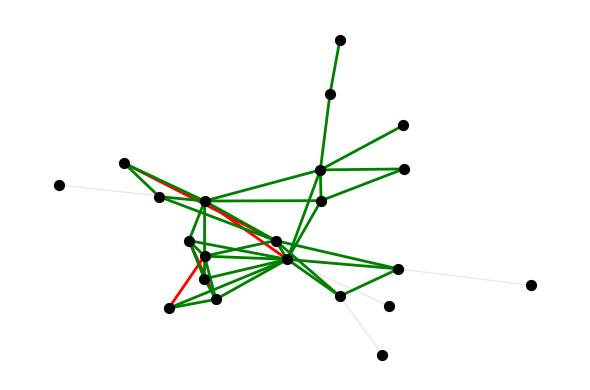

Overlap: 0.8974358974358975


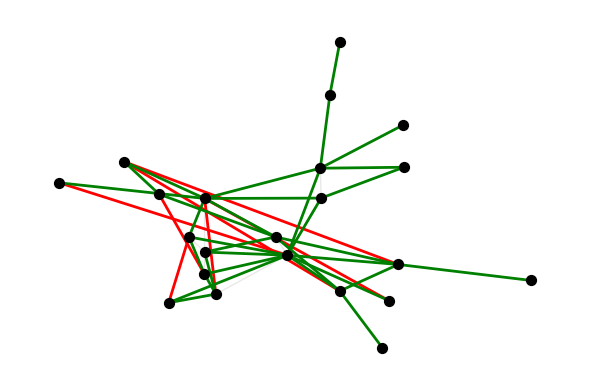

Overlap: 0.8205128205128205
############################################################


In [18]:
disease_list = ["craniosynostosis", "blindness"]
plot_reconstr_for_disease_group(disease_list)

k =  5


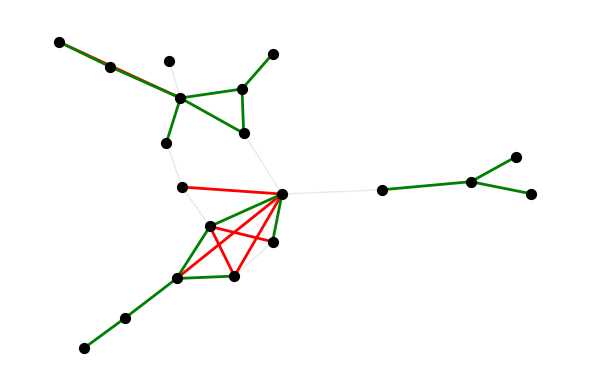

Overlap: 0.7272727272727273


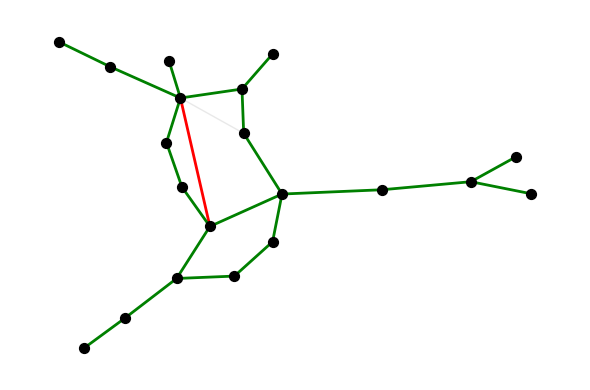

Overlap: 0.9545454545454546
############################################################
k =  5


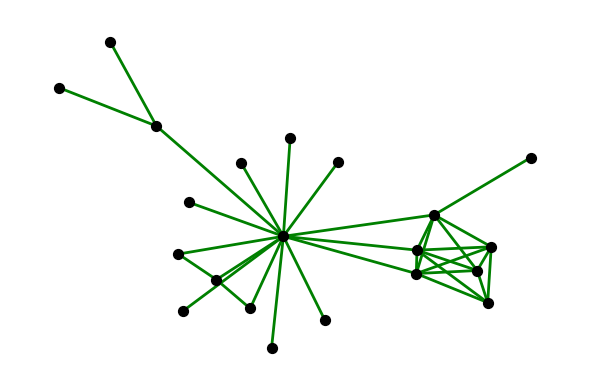

Overlap: 1.0


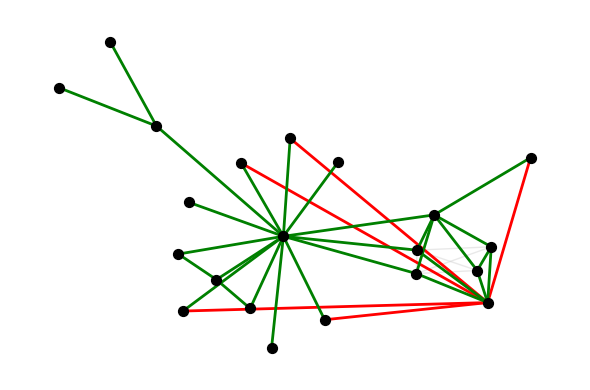

Overlap: 0.8484848484848485
############################################################
k =  5


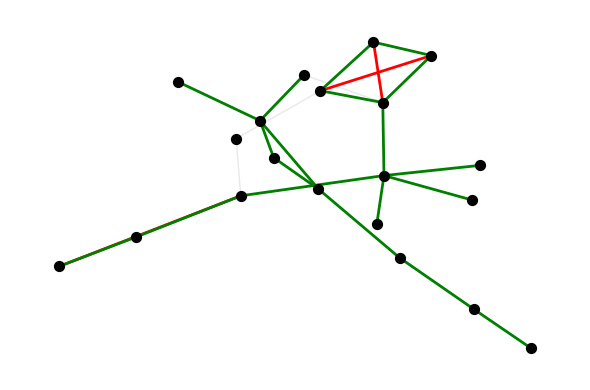

Overlap: 0.8636363636363636


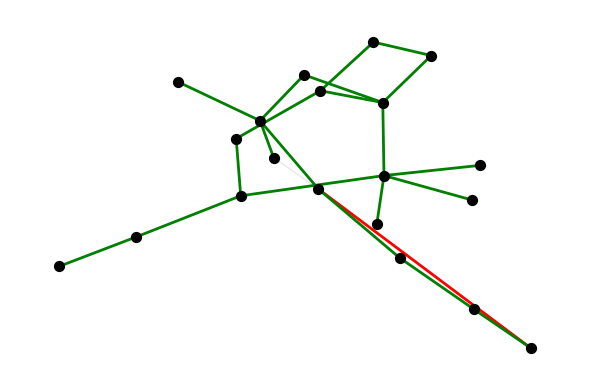

Overlap: 0.9545454545454546
############################################################
k =  8


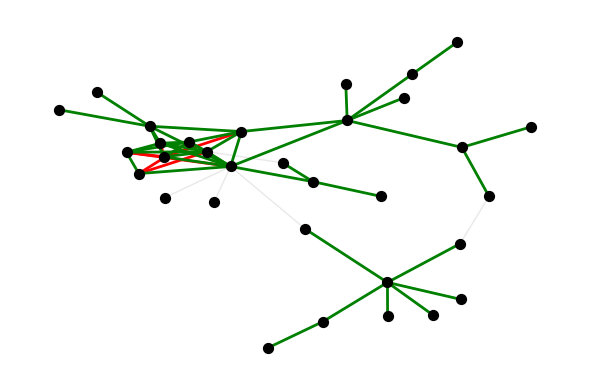

Overlap: 0.875


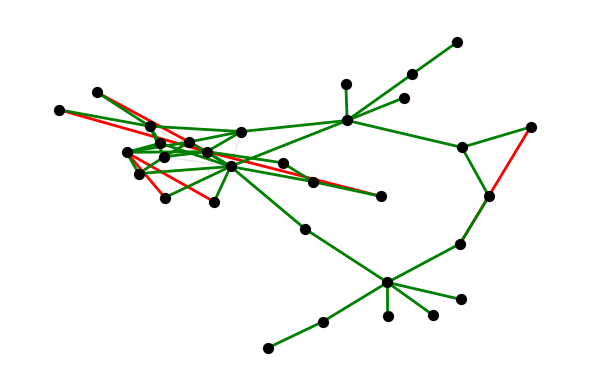

Overlap: 0.875
############################################################
k =  8


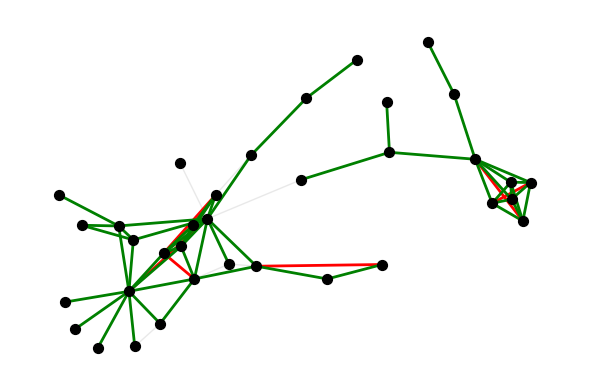

Overlap: 0.9


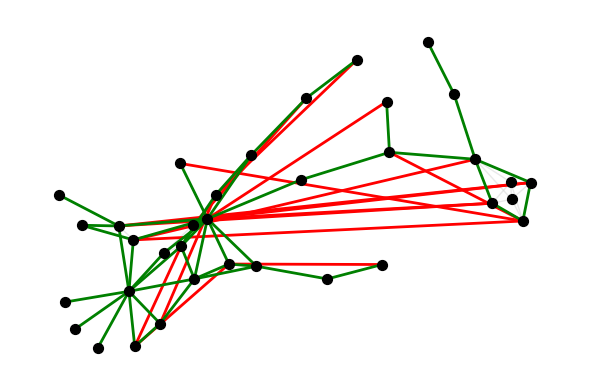

Overlap: 0.75
############################################################


In [20]:
disease_list = ["aortic valve disease", "amnestic disorder", "middle ear disease",
               "esophagus squamous cell carcinoma", "retinitis pigmentosa"]
plot_reconstr_for_disease_group(disease_list)

In [23]:
# Same funnction but without plot (for larger graphs)

def reconstruct_lcc_graph_no_plot(disease_name, k, method):
    disease_id = name_to_doid[disease_name]
    lcc_nodes, lcc = compute_lcc_of_disease(disease_id)
    L_lcc = nx.normalized_laplacian_matrix(lcc).toarray()
    eigenvalues, eigenvectors = LA.eigh(L_lcc)
    
    
    if method == 'first_k':
        selected_indices = np.arange(k)
    elif method == 'last_k':
        selected_indices = np.arange(-k, 0)
    elif method == 'first_last_k_over_2':
        k_half = k // 2
        selected_indices = np.concatenate([np.arange(k_half), np.arange(-k_half, 0)])
    else:
        raise ValueError(f"Unknown method: {method}")

    
    
    # Reconstruct the adjacency matrix
    U_k = eigenvectors[:, selected_indices]
    lambda_k = eigenvalues[selected_indices]
    S_k = U_k @ np.diag(1 - lambda_k) @ U_k.T
    degrees = np.array([d for _, d in lcc.degree()])
    D_sqrt = np.diag(np.sqrt(degrees))
    A_k = D_sqrt @ S_k @ D_sqrt

    # Cleaning
    np.fill_diagonal(A_k, 0)
    A_k = (A_k + A_k.T) / 2
    A_k[A_k < 0] = 0
    

    # Reconstruct the graph from the adjacency matrix
    reconstructed_graph = nx.Graph()
    
    N = len(lcc.edges())  # Number of edges in original graph

    n = A_k.shape[0]

    for i in range(n):
        for j in range(i+1, n):
            weight = A_k[i, j]
            if weight > 0:
                reconstructed_graph.add_edge(i, j, weight=weight)
                
                
    # Sort edges by descending weight
    edges_with_weights = sorted(
        [(u, v, d['weight']) for u, v, d in reconstructed_graph.edges(data=True)],
        key=lambda x: x[2],
        reverse=True
    )

    # Initialize an empty graph with the same nodes as original one
    top_graph = nx.Graph()
    top_graph.add_nodes_from(reconstructed_graph.nodes())

    # Add edges until the graph has the same number of edges as original one
    for u, v, w in edges_with_weights:
        top_graph.add_edge(u, v, weight=w)
        if top_graph.number_of_edges() == lcc.number_of_edges():
            break
          
          
           
                
    # Get the node labels from lcc in the same order as used to compute the Laplacian matrix
    original_nodes = list(lcc.nodes())

    # Relabel the nodes in reconstructed_graph
    mapping = {i: node for i, node in enumerate(original_nodes)}
    top_graph = nx.relabel_nodes(top_graph, mapping)


    # Edges
    original_edges = set(tuple(sorted(edge)) for edge in lcc.edges())
    reconstructed_edges = set(tuple(sorted(edge)) for edge in top_graph.edges())

    tp = len(original_edges & reconstructed_edges)
    overlap = tp/N

    print("Overlap:", overlap)  
    return overlap

In [25]:
# Function that computes all three reconstructions (based on first/last/first-last eigenpairs) for a list of diseases

def plot_reconstr_for_disease_group_no_plot(disease_list):
    for disease in disease_list:
        disease_id = name_to_doid[disease]
        lcc_nodes, lcc = compute_lcc_of_disease(disease_id)
        number_of_nodes_in_lcc = len(lcc_nodes)
        print(disease)
        print("k = ", number_of_nodes_in_lcc//4)
        print(print_graph_stats(lcc))
        reconstruct_lcc_graph_no_plot(disease, number_of_nodes_in_lcc//4, 'first_k')
        #print("\n")
        reconstruct_lcc_graph_no_plot(disease, number_of_nodes_in_lcc//4, 'last_k')
        #print("\n")
        reconstruct_lcc_graph_no_plot(disease, number_of_nodes_in_lcc//4, 'first_last_k_over_2')
        print("############################################################")

In [27]:
selected_diseases_100_200_3_10= [
    "mechanical strabismus",
    "cataract",
    "hypertropia",
    "hyperopia",
    "colorectal cancer",
    "glomerulonephritis"
]
plot_reconstr_for_disease_group_no_plot(selected_diseases_100_200_3_10)

mechanical strabismus
k =  39
Number of nodes: 156
Number of edges: 315
Average degree: 4.038461538461538
Max degree: 16
Min degree: 1
Average clustering coefficient: 0.22352088794396485
Diameter: 10
None
Overlap: 0.9079365079365079
Overlap: 0.8444444444444444
Overlap: 0.8412698412698413
############################################################
cataract
k =  33
Number of nodes: 133
Number of edges: 221
Average degree: 3.3233082706766917
Max degree: 14
Min degree: 1
Average clustering coefficient: 0.2069836178858735
Diameter: 10
None
Overlap: 0.9095022624434389
Overlap: 0.8552036199095022
Overlap: 0.8552036199095022
############################################################
hypertropia
k =  38
Number of nodes: 154
Number of edges: 312
Average degree: 4.0519480519480515
Max degree: 16
Min degree: 1
Average clustering coefficient: 0.22644999300843457
Diameter: 10
None
Overlap: 0.9038461538461539
Overlap: 0.842948717948718
Overlap: 0.8493589743589743
##################################

### Experiment with large lists of diseases 

In [29]:
disease_list = ['autosomal recessive Robinow syndrome', 'peripheral nervous system neoplasm', 'nervous system benign neoplasm', 'Bardet-Biedl syndrome 18', 'dilated cardiomyopathy 1D', 'brain edema', 'osteosarcoma', 'fibrillary astrocytoma', 'autosomal recessive limb-girdle muscular dystrophy type 2O', 'salivary gland adenoid cystic carcinoma', "Addison's disease", 'Cornelia de Lange syndrome', 'Hailey-Hailey disease', 'brain infarction', 'childhood medulloblastoma', "Richter's syndrome", 'obstructive hydrocephalus', 'phobic disorder', 'reactive cutaneous fibrous lesion', "Alzheimer's disease 14", 'cutis laxa', 'hemangioma', 'adrenocortical carcinoma', 'amyloidosis', 'gliosarcoma', 'Sheehan syndrome', 'hydrocephalus', 'nonepidermolytic palmoplantar keratoderma', 'obsolete inherited blood coagulation disease', 'B-cell lymphoma', 'obsolete T-cell lymphoblastic leukemia/lymphoma', 'sweat gland cancer', 'acoustic neuroma', 'cannabis dependence', 'uterine corpus sarcoma', 'photosensitive epilepsy', 'lingual-facial-buccal dyskinesia', 'nasopharynx carcinoma', 'esophageal atresia', 'dermis tumor', 'transitional cell carcinoma', 'essential thrombocythemia', 'infratentorial cancer', 'mature T-cell and NK-cell lymphoma', 'amnestic disorder', 'bone osteosarcoma', 'tuberous sclerosis', 'migraine', 'ichthyosis', 'supratentorial cancer', 'myocardial infarction', 'skin carcinoma', 'uterine corpus cancer', 'brain ischemia', 'Duchenne muscular dystrophy', 'amyotrophic lateral sclerosis', 'cerebral ventricle cancer', 'esophageal carcinoma', 'lactic acidosis', 'middle ear disease', 'thyroid cancer', 'bile duct carcinoma', 'central nervous system lymphoma', 'neurilemmoma', "Sezary's disease", 'Noonan syndrome 1', 'congenital structural myopathy', 'epithelioid sarcoma', 'esophagus squamous cell carcinoma', 'skin hemangioma', 'cervical cancer', 'Stevens-Johnson syndrome', 'lymphatic system cancer', 'lymphatic system disease', 'pituitary gland disease', 'obsolete benign glioma', 'tooth agenesis', 'salivary gland carcinoma', 'aortic valve disease', 'medulloblastoma', 'pituitary adenoma', 'Klippel-Feil syndrome', 'bulimia nervosa', 'bone cancer', 'obsolete ymphosarcoma', 'sebaceous gland neoplasm', 'gastric outlet obstruction', 'lung small cell carcinoma', 'dilated cardiomyopathy 1KK', 'X-linked monogenic disease', 'thyroid adenoma', 'autonomic nervous system neoplasm', 'ventricular septal defect', 'uterine cancer', 'acquired hyperkeratosis', 'mitral valve insufficiency', 'distal myopathy', 'endocrine organ benign neoplasm', 'cerebral infarction', 'endometrial carcinoma', 'oral cavity cancer', 'B cell deficiency', 'Leigh disease', 'pancreatic carcinoma', 'pulmonary valve disease', 'photosensitivity disease', 'sebaceous adenoma', 'papilloma', 'focal hand dystonia', 'biliary tract cancer', 'acute lymphoblastic leukemia', 'lung adenocarcinoma', 'mitral valve disease', 'adrenal cortex cancer', "Barrett's esophagus", 'squamous cell papilloma', 'chondrodysplasia punctata', 'bladder carcinoma', 'dilated cardiomyopathy 1CC', 'progressive muscular atrophy', 'hyperglycemia', 'dilated cardiomyopathy 2B', 'generalized anxiety disorder', 'lymphangioma', "Parkinson's disease", 'retrograde amnesia', 'cardiovascular cancer', 'congenital hypoplastic anemia', 'secondary Parkinson disease', 'aplastic anemia', 'bladder urothelial carcinoma', 'sarcoma', 'muscular dystrophy', 'vascular hemostatic disease', 'leukocyte disease', 'restrictive dermopathy', 'myeloproliferative neoplasm', 'palmoplantar keratosis', 'bone structure disease', 'dilated cardiomyopathy', 'autosomal dominant cerebellar ataxia', 'senile degeneration of brain', 'mitochondrial complex I deficiency', 'mixed glioma', 'synucleinopathy', 'hereditary ataxia']
filtered_disease_list = []

for disease_name in disease_list:
    disease_id = name_to_doid[disease_name]
    lcc_nodes, lcc = compute_lcc_of_disease(disease_id)
    
    if lcc.number_of_nodes() >= 20:
        filtered_disease_list.append(disease_name)

print(len(filtered_disease_list)) 

87


In [31]:
# Uncomment when running

#plot_reconstr_for_disease_group_no_plot(filtered_disease_list)

In [34]:
def collect_overlap_scores(disease_list):
    results = []

    for disease in disease_list:
        disease_id = name_to_doid[disease]
        lcc_nodes, lcc = compute_lcc_of_disease(disease_id)

        k = len(lcc_nodes) // 4

        overlap_first = reconstruct_lcc_graph_no_plot(disease, k, 'first_k')
        overlap_last = reconstruct_lcc_graph_no_plot(disease, k, 'last_k')
        overlap_half = reconstruct_lcc_graph_no_plot(disease, k, 'first_last_k_over_2')

        results.append({
            "disease": disease,
            "first": overlap_first,
            "last": overlap_last,
            "half": overlap_half
        })

    return results

In [35]:
# Group diseases based on which reconstruction gave the best overlap

from collections import defaultdict

grouped = defaultdict(list)

results = collect_overlap_scores(disease_list)


for r in results:
    f, l, h = r["first"], r["last"], r["half"]

    max_overlap = max(f, l, h)

    if h == max_overlap and h > f and h > l:
        grouped["half"].append(r["disease"])

    else:
        if f == max_f1:
            grouped["first"].append(r["disease"])
        if l == max_f1:
            grouped["last"].append(r["disease"])

Overlap: 0.9354838709677419
Overlap: 0.9032258064516129
Overlap: 0.7096774193548387
Overlap: 0.8653846153846154
Overlap: 0.8653846153846154
Overlap: 0.8461538461538461
Overlap: 0.8285714285714286
Overlap: 0.9142857142857143
Overlap: 0.8571428571428571
Overlap: 0.9722222222222222
Overlap: 0.5
Overlap: 0.8888888888888888
Overlap: 0.8627450980392157
Overlap: 0.9411764705882353
Overlap: 0.7058823529411765
Overlap: 0.9318181818181818
Overlap: 0.75
Overlap: 0.8409090909090909
Overlap: 0.8518518518518519
Overlap: 0.8888888888888888
Overlap: 0.8888888888888888
Overlap: 0.9
Overlap: 0.8
Overlap: 0.9
Overlap: 0.9
Overlap: 0.9
Overlap: 0.7
Overlap: 0.9180327868852459
Overlap: 0.9180327868852459
Overlap: 0.8360655737704918
Overlap: 0.9259259259259259
Overlap: 0.8518518518518519
Overlap: 0.6666666666666666
Overlap: 0.8666666666666667
Overlap: 0.8333333333333334
Overlap: 0.7
Overlap: 0.8571428571428571
Overlap: 0.8571428571428571
Overlap: 0.7619047619047619
Overlap: 0.9056603773584906
Overlap: 0.962

Overlap: 0.8809523809523809
Overlap: 0.7976190476190477
Overlap: 0.8421052631578947
Overlap: 0.631578947368421
Overlap: 0.5789473684210527
Overlap: 0.9428571428571428
Overlap: 0.7428571428571429
Overlap: 0.7142857142857143
Overlap: 0.8888888888888888
Overlap: 1.0
Overlap: 0.8888888888888888
Overlap: 0.7692307692307693
Overlap: 0.8461538461538461
Overlap: 0.9230769230769231
Overlap: 0.8333333333333334
Overlap: 0.8
Overlap: 0.8
Overlap: 0.75
Overlap: 0.8
Overlap: 0.6
Overlap: 0.8653846153846154
Overlap: 0.9038461538461539
Overlap: 0.7115384615384616
Overlap: 0.84
Overlap: 0.92
Overlap: 0.6
Overlap: 0.7727272727272727
Overlap: 0.8636363636363636
Overlap: 0.6818181818181818
Overlap: 0.8461538461538461
Overlap: 0.8846153846153846
Overlap: 0.7307692307692307
Overlap: 0.9318181818181818
Overlap: 0.9545454545454546
Overlap: 0.7045454545454546
Overlap: 0.8846153846153846
Overlap: 0.8846153846153846
Overlap: 0.8846153846153846
Overlap: 0.975609756097561
Overlap: 0.8780487804878049
Overlap: 0.804

In [139]:
grouped

defaultdict(list,
            {'first': ['autosomal recessive Robinow syndrome',
              'peripheral nervous system neoplasm',
              'autosomal recessive limb-girdle muscular dystrophy type 2O',
              'salivary gland adenoid cystic carcinoma',
              'childhood medulloblastoma',
              'reactive cutaneous fibrous lesion',
              'hemangioma',
              'obsolete inherited blood coagulation disease',
              'sweat gland cancer',
              'lingual-facial-buccal dyskinesia',
              'dermis tumor',
              'infratentorial cancer',
              'amnestic disorder',
              'migraine',
              'supratentorial cancer',
              'myocardial infarction',
              'skin carcinoma',
              'brain ischemia',
              'lactic acidosis',
              'thyroid cancer',
              'esophagus squamous cell carcinoma',
              'lymphatic system disease',
              'obsolete benign gli